# China — Monthly Notifiable Disease Overviews, CNIC Influenza & COVID Reports

The `china_cdc` accessor covers **four complementary mainland-China sources**. The
journal side (China CDC Weekly, discovered via CrossRef) is demonstrated in
*15_China_CDC_Weekly_Surveillance.ipynb*; this notebook focuses on the
direct-report pipelines:

- **NDCPA monthly overviews** (国家疾病预防控制局, mirrored on chinacdc.cn): official
  per-disease case/death tables for all statutory Class A/B/C diseases **plus** the
  priority-monitored non-notifiable diseases (e.g. chickenpox, liver fluke disease)
- **CNIC weekly influenza reports** (Chinese National Influenza Center): sentinel ILI%
  for southern/northern provinces and laboratory positivity by type/subtype
- **Monthly national COVID-19 situation reports** (chinacdc.cn)

All listings are server-rendered HTML, so no CrossRef or JavaScript rendering is needed.

## 1. Setup

In [1]:
from epidatasets.sources.china_cdc import ChinaCDCAccessor

ccdc = ChinaCDCAccessor()  # listings fetched live; PDFs cached with 365-day TTL

ccdc.list_notifiable_diseases().head(8)

,disease_code,disease_name_cn,category
0,Plague,鼠疫,Class A
1,Cholera,霍乱,Class A
2,SARS,传染性非典型肺炎,Class B
3,AIDS,艾滋病,Class B
4,Viral_Hepatitis,病毒性肝炎,Class B
5,Polio,脊髓灰质炎,Class B
6,Human_Avian_Influenza,人感染高致病性禽流感,Class B
7,Measles,麻疹,Class B


## 2. Monthly notifiable disease overviews

Each month the NDCPA publishes a per-disease table (法定传染病疫情概况). The accessor
scrapes the chinacdc.cn mirror listing and parses the Chinese table into the same
canonical schema used for the China CDC Weekly reports, mapping Chinese disease names
to codes via the accessor's built-in dictionary.

In [2]:
overview = ccdc.list_monthly_overviews(year=2026)
overview

INFO:epidatasets.sources.china_cdc:Listing monthly notifiable disease overviews


INFO:epidatasets.sources.china_cdc:Found 7 listing entries at https://www.chinacdc.cn/jksj/jksj01/


INFO:epidatasets.sources.china_cdc:Found 7 monthly overviews


,year,month,title,published_date,url
0,2026,1,2026年1月全国传染病疫情概况,2026-02-10,https://www.chinacdc.cn/jksj/jksj01/202602/t20...
1,2026,2,2026年2月全国传染病疫情概况,2026-03-12,https://www.chinacdc.cn/jksj/jksj01/202603/t20...
2,2026,3,2026年3月全国传染病疫情概况,2026-04-10,https://www.chinacdc.cn/jksj/jksj01/202604/t20...
3,2026,4,2026年4月全国传染病疫情概况,2026-05-13,https://www.chinacdc.cn/jksj/jksj01/202605/t20...
4,2026,5,2026年5月全国传染病疫情概况,2026-06-10,https://www.chinacdc.cn/jksj/jksj01/202606/t20...
5,2026,6,2026年6月全国传染病疫情概况,2026-07-08,https://www.chinacdc.cn/jksj/jksj01/202607/t20...
6,2026,7,2026年7月全国传染病疫情概况,2026-08-13,https://www.chinacdc.cn/jksj/jksj01/202608/t20...


In [3]:
jul = ccdc.get_monthly_overview(2026, 7)
print(f"{len(jul)} disease rows for 2026-07")
jul[jul["category"] == "Class A"]

INFO:epidatasets.sources.china_cdc:Listing monthly notifiable disease overviews


INFO:epidatasets.sources.china_cdc:Found 7 listing entries at https://www.chinacdc.cn/jksj/jksj01/


INFO:epidatasets.sources.china_cdc:Found 7 monthly overviews


INFO:epidatasets.sources.china_cdc:Parsed 55 disease rows for 2026-07


55 disease rows for 2026-07


,year,month,disease_code,disease_cn,cases,deaths,category,is_subitem,source_url
0,2026,7,Plague,鼠疫,0,0,Class A,False,https://www.chinacdc.cn/jksj/jksj01/202608/t20...
1,2026,7,Cholera,霍乱,4,0,Class A,False,https://www.chinacdc.cn/jksj/jksj01/202608/t20...


In [4]:
# Class B totals and the top-level diseases (hepatitis subtypes are flagged as sub-items)
class_b = jul[jul["category"] == "Class B"]
class_b[~class_b["is_subitem"]].nlargest(5, "cases")[
    ["disease_code", "disease_cn", "cases", "deaths"]
]

,disease_code,disease_cn,cases,deaths
2,COVID_19,新型冠状病毒感染,521751,1
5,Viral_Hepatitis,病毒性肝炎,147945,284
24,TB,肺结核,58871,190
33,Syphilis,梅毒,58058,2
32,Gonorrhea,淋病,13411,0


### The unique extra: priority-monitored non-notifiable diseases

Since January 2026 the monthly overviews also include a "key monitored" section with
diseases that are **not** statutorily notifiable — data unavailable anywhere else
in this package.

In [5]:
monitored = jul[jul["category"] == "Monitored (non-notifiable)"]
monitored[["disease_code", "disease_cn", "cases", "deaths"]]

,disease_code,disease_cn,cases,deaths
48,中东呼吸综合征（MERS）,中东呼吸综合征（MERS）,0,0
49,Ebola,埃博拉出血热,0,0
50,Zika,寨卡病毒病,5,0
51,Lassa_Fever,拉沙热,0,0
52,Chickenpox,水痘,46105,0
53,Liver_Fluke,肝吸虫病,12460,0
54,Streptococcus_Suis,人感染猪链球菌病,68,0


### Monthly and annual summaries

In [6]:
ccdc.get_monthly_summary(2026, 7)

INFO:epidatasets.sources.china_cdc:Listing monthly notifiable disease overviews


INFO:epidatasets.sources.china_cdc:Found 7 listing entries at https://www.chinacdc.cn/jksj/jksj01/


INFO:epidatasets.sources.china_cdc:Found 7 monthly overviews


,year,month,scope,cases,deaths,top_diseases,source_url
0,2026,7,notifiable_total,2150320,2107,None,https://www.chinacdc.cn/jksj/jksj01/202608/t20...
1,2026,7,class_ab,820877,2104,新型冠状病毒感染、病毒性肝炎、肺结核、梅毒、淋病,https://www.chinacdc.cn/jksj/jksj01/202608/t20...
2,2026,7,class_c,1329443,3,流行性感冒、手足口病、其他感染性腹泻病,https://www.chinacdc.cn/jksj/jksj01/202608/t20...
3,2026,7,monitored,58638,0,None,https://www.chinacdc.cn/jksj/jksj01/202608/t20...


In [7]:
# aggregates every available month of 2026 (fetches each monthly page)
annual = ccdc.get_annual_summary(2026)
annual.nlargest(8, "total_cases")[["disease_cn", "category", "total_cases", "total_deaths", "months_reported"]]

INFO:epidatasets.sources.china_cdc:Building annual overview summary for 2026


INFO:epidatasets.sources.china_cdc:Listing monthly notifiable disease overviews


INFO:epidatasets.sources.china_cdc:Found 7 listing entries at https://www.chinacdc.cn/jksj/jksj01/


INFO:epidatasets.sources.china_cdc:Found 7 monthly overviews


,disease_cn,category,total_cases,total_deaths,months_reported
19,流行性感冒,Class C,4908581,13,7
18,其他感染性腹泻病,Class C,1229889,0,7
46,病毒性肝炎,Class B,935194,1198,7
48,乙型肝炎,Monitored (non-notifiable),797007,230,7
17,手足口病,Class C,745239,1,7
4,新型冠状病毒感染,Class B,709672,11,7
44,肺结核,Class B,394450,1191,7
43,梅毒,Class B,391763,20,7


## 3. CNIC weekly influenza surveillance

The Chinese National Influenza Center publishes an English weekly report per week.
The accessor lists the reports, downloads the PDFs (cached) and parses the ILI%
sentinel rates and the laboratory Table 1.

In [8]:
reports = ccdc.list_cnic_weekly_reports(year=2025, max_pages=3)
reports.tail()

INFO:epidatasets.sources.china_cdc:Found 23 CNIC weekly reports


,year,week,title,report_date,url
18,2025,48,Week 48 2025,2025-12-03,https://ivdc.chinacdc.cn/cnic/en/Surveillance/...
19,2025,49,Week 49 2025,2025-12-11,https://ivdc.chinacdc.cn/cnic/en/Surveillance/...
20,2025,50,Week 50 2025,2025-12-18,https://ivdc.chinacdc.cn/cnic/en/Surveillance/...
21,2025,51,Week 51 2025,2025-12-21,https://ivdc.chinacdc.cn/cnic/en/Surveillance/...
22,2025,52,Week 52 2025,2025-01-01,https://ivdc.chinacdc.cn/cnic/en/Surveillance/...


In [9]:
flu = ccdc.get_influenza_surveillance(year=2025, weeks=[35, 36, 37])
flu[["year", "week", "period", "ili_percent_south", "ili_percent_north",
     "specimens_tested", "positivity_rate", "ili_outbreaks"]]

INFO:epidatasets.sources.china_cdc:Fetching CNIC influenza surveillance for year=2025


INFO:epidatasets.sources.china_cdc:Found 52 CNIC weekly reports


INFO:epidatasets.utils.pdf:Using cached PDF: /home/fccoelho/.cache/epidatasets/china_cdc/P020250904558511053629.pdf


INFO:epidatasets.utils.pdf:Using cached PDF: /home/fccoelho/.cache/epidatasets/china_cdc/P020250911793131152379.pdf


INFO:epidatasets.utils.pdf:Using cached PDF: /home/fccoelho/.cache/epidatasets/china_cdc/P020250919338683096236.pdf


,year,week,period,ili_percent_south,ili_percent_north,specimens_tested,positivity_rate,ili_outbreaks
0,2025,35,"August 25 to 31, 2025",3.1,2.5,12774,2.2,NaN
1,2025,36,"September 1 to 7, 2025",3.4,2.7,12879,2.2,NaN
2,2025,37,"September 8 to 14, 2025",3.6,2.8,13320,2.5,7.0


In [10]:
week37 = flu.iloc[-1]
import pandas as pd

pd.DataFrame(week37["by_type"]).T  # Table 1: laboratory detections by type/subtype

,south_count,south_pct,north_count,north_pct,total_count,total_pct
Influenza A,293.0,89.1,7.0,100.0,300.0,89.3
Influenza B,36.0,10.9,0.0,NaN,36.0,10.7
A(H1N1)pdm09,19.0,6.5,1.0,14.3,20.0,6.7
A(H3N2),274.0,93.5,6.0,85.7,280.0,93.3
A (subtype not determined),0.0,NaN,0.0,NaN,0.0,NaN
B (lineage not determined),0.0,NaN,0.0,NaN,0.0,NaN
Victoria,36.0,100.0,0.0,NaN,36.0,100.0
Yamagata,0.0,NaN,0.0,NaN,0.0,NaN


## 4. Monthly COVID-19 situation reports

chinacdc.cn publishes a monthly national COVID-19 report; the accessor extracts the
headline counts (handling the 万 = 10k unit used in the prose).

In [11]:
covid = ccdc.get_covid_updates()
covid[["year", "month", "new_cases", "severe_cases", "new_deaths"]].tail(6)

INFO:epidatasets.sources.china_cdc:Fetching monthly COVID-19 updates from chinacdc.cn


INFO:epidatasets.sources.china_cdc:Found 39 listing entries at https://www.chinacdc.cn/jksj/xgbdyq/


,year,month,new_cases,severe_cases,new_deaths
33,2026,2,19453.0,54,1
34,2026,3,26306.0,60,2
35,2026,4,23477.0,64,4
36,2026,5,21861.0,35,1
37,2026,6,79000.0,130,1
38,2026,7,522000.0,487,1


## 5. Putting it together — influenza on both sides of the border

The CNIC series (mainland) and the Hong Kong Flu Express (`hk_chp` accessor) can be
compared directly.

INFO:epidatasets.sources.hk_chp:Using cached CSV: /home/fccoelho/.cache/epidatasets/hk_chp/flux_data.csv


INFO:epidatasets.sources.hk_chp:Retrieved 52 weekly influenza records


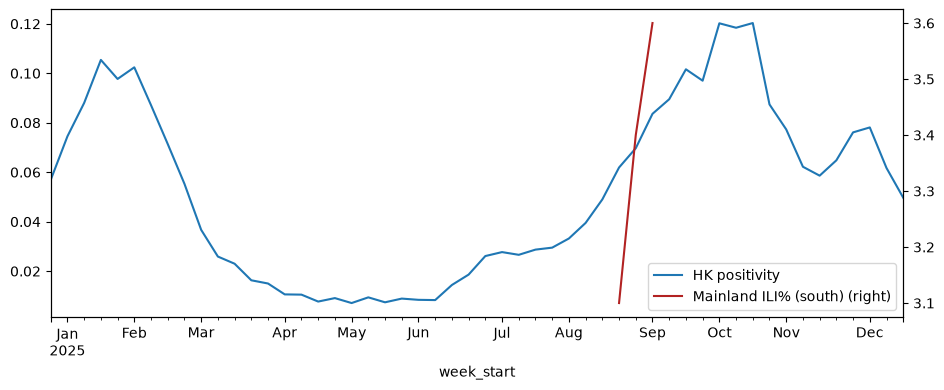

In [12]:
# requires network; both series are cached after the first fetch
from epidatasets.sources.hk_chp import HongKongCHPAccessor

hk = HongKongCHPAccessor()
hk_flu = hk.get_influenza_positivity(year=2025).set_index("week_start")
cn_ili = flu.dropna(subset=["ili_percent_south"]).assign(
    week_start=pd.to_datetime(flu["period"].str.split(" to ").str[0] + ", 2025",
                              format="%B %d, %Y")
).set_index("week_start")

ax = hk_flu["influenza_positivity"].plot(figsize=(11, 4), label="HK positivity", legend=True)
cn_ili["ili_percent_south"].plot(secondary_y=True, ax=ax, color="firebrick",
                                 label="Mainland ILI% (south)", legend=True);